
=== Decay of modes after t = tau ===
Mode n    Decay factor      Relative to n=1   
1         0.367879          1.000000          
3         0.000123          0.000335          
5         0.000000          0.000000          
7         0.000000          0.000000          
9         0.000000          0.000000          

Characteristic timescale tau = 10.1321


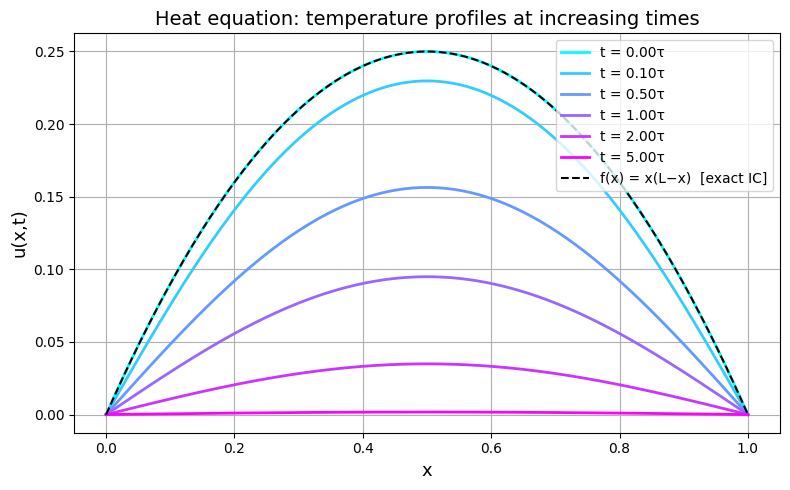

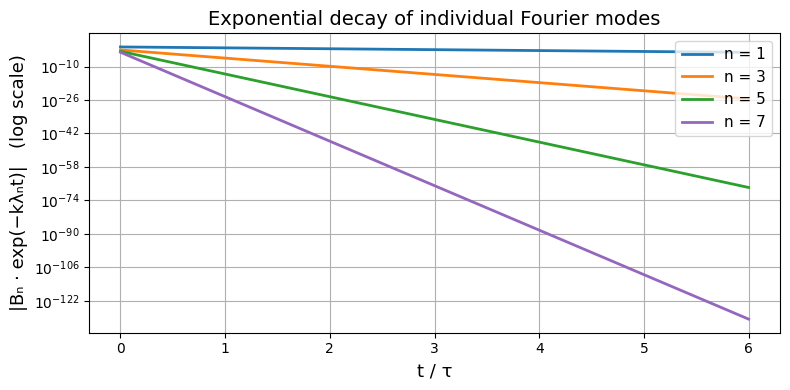

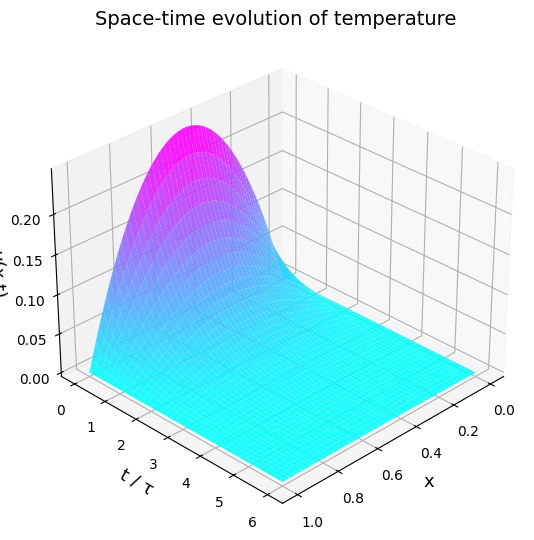

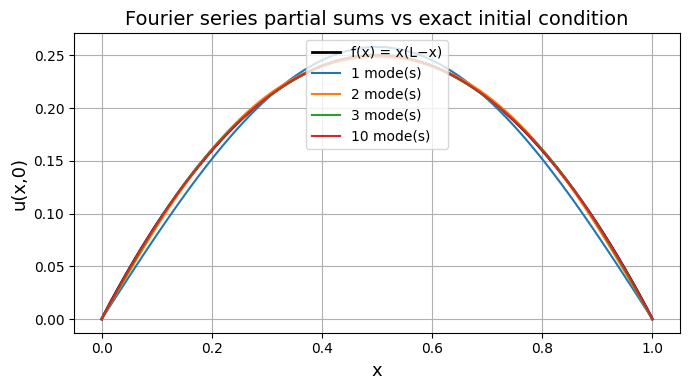

In [1]:
# =========================================================
#  Heat equation simulation: parabolic initial condition
#  u_t = k * u_xx,  x in [0,L],  t >= 0
#  BCs: u(0,t) = u(L,t) = 0
#  IC:  u(x,0) = x*(L-x)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ── Parameters ────────────────────────────────────────────
L   = 1        # rod length
k   = 0.01     # thermal conductivity
N   = 50       # number of Fourier modes (odd only)
tau = L**2 / (k * np.pi**2)   # characteristic decay timescale

# ── Spatial and temporal grids ────────────────────────────
x      = np.linspace(0, L, 300)
t_plot = np.array([0, 0.1, 0.5, 1, 2, 5]) * tau

# ── Fourier coefficients  B_n = 8L² / (n³π³)  for odd n ─
odd_n = np.arange(1, 2*N, 2)          # n = 1, 3, 5, …
B     = 8 * L**2 / (odd_n**3 * np.pi**3)


def fourier_sum(x, t, odd_n, B, k, L):
    """Evaluate the truncated Fourier series at given x and scalar t."""
    u = np.zeros_like(x, dtype=float)
    for n, b in zip(odd_n, B):
        u += b * np.sin(n * np.pi * x / L) * np.exp(-k * n**2 * np.pi**2 * t / L**2)
    return u


# ── Figure 1: temperature profiles at selected times ──────
fig1, ax1 = plt.subplots(figsize=(8, 5))
colors = cm.cool(np.linspace(0, 1, len(t_plot)))

for i, t in enumerate(t_plot):
    u = fourier_sum(x, t, odd_n, B, k, L)
    ax1.plot(x, u, color=colors[i], linewidth=2,
             label=f't = {t/tau:.2f}τ')

# Overlay exact initial condition
u0 = x * (L - x)
ax1.plot(x, u0, 'k--', linewidth=1.5, label='f(x) = x(L−x)  [exact IC]')

ax1.set_xlabel('x', fontsize=13)
ax1.set_ylabel('u(x,t)', fontsize=13)
ax1.set_title('Heat equation: temperature profiles at increasing times', fontsize=14)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True); ax1.set_box_aspect(None)
fig1.tight_layout()


# ── Figure 2: mode-by-mode decay (log scale) ──────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
t_fine      = np.linspace(0, 6*tau, 500)
mode_colors = plt.cm.tab10(np.linspace(0, 0.4, 4))

for idx in range(4):
    n   = odd_n[idx]
    amp = B[idx] * np.exp(-k * n**2 * np.pi**2 * t_fine / L**2)
    ax2.semilogy(t_fine / tau, np.abs(amp),
                 color=mode_colors[idx], linewidth=2,
                 label=f'n = {n}')

ax2.set_xlabel('t / τ', fontsize=13)
ax2.set_ylabel('|Bₙ · exp(−kλₙt)|   (log scale)', fontsize=13)
ax2.set_title('Exponential decay of individual Fourier modes', fontsize=14)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True)
fig2.tight_layout()


# ── Figure 3: waterfall / surface plot ────────────────────
t_water = np.linspace(0, 6*tau, 80)
U       = np.array([fourier_sum(x, t, odd_n, B, k, L) for t in t_water])

X_grid, T_grid = np.meshgrid(x, t_water / tau)

fig3  = plt.figure(figsize=(7, 5.5))
ax3   = fig3.add_subplot(111, projection='3d')
ax3.plot_surface(X_grid, T_grid, U, cmap='cool',
                 linewidth=0, antialiased=True, alpha=0.9)

ax3.set_xlabel('x', fontsize=13)
ax3.set_ylabel('t / τ', fontsize=13)
ax3.set_zlabel('u(x,t)', fontsize=13)
ax3.set_title('Space-time evolution of temperature', fontsize=14)
ax3.view_init(elev=30, azim=45)
fig3.tight_layout()


# ── Figure 4: Fourier partial sums at t=0 (convergence) ───
fig4, ax4 = plt.subplots(figsize=(7, 4))
f_exact = x * (L - x)
ax4.plot(x, f_exact, 'k-', linewidth=2, label='f(x) = x(L−x)')

for M in [1, 2, 3, 10]:
    u_trunc = np.zeros_like(x, dtype=float)
    for idx in range(M):
        n        = odd_n[idx]
        u_trunc += B[idx] * np.sin(n * np.pi * x / L)
    ax4.plot(x, u_trunc, linewidth=1.5, label=f'{M} mode(s)')

ax4.set_xlabel('x', fontsize=13)
ax4.set_ylabel('u(x,0)', fontsize=13)
ax4.set_title('Fourier series partial sums vs exact initial condition', fontsize=14)
ax4.legend(loc='upper center', fontsize=10)
ax4.grid(True)
fig4.tight_layout()


# ── Console output: quantitative decay summary ────────────
print('\n=== Decay of modes after t = tau ===')
print(f'{"Mode n":<10}{"Decay factor":<18}{"Relative to n=1":<18}')
ref = np.exp(-k * np.pi**2 * tau / L**2)
for idx in range(5):
    n  = odd_n[idx]
    df = np.exp(-k * n**2 * np.pi**2 * tau / L**2)
    print(f'{n:<10}{df:<18.6f}{df/ref:<18.6f}')

print(f'\nCharacteristic timescale tau = {tau:.4f}')

plt.show()


=== Decay of modes after t = tau ===
Mode n    Bn            Decay factor      Relative to n=1   
1         -0.63662      0.367879          1.000000          
2         -0.31831      0.018316          0.049787          
3         -0.21221      0.000123          0.000335          
4         -0.15915      0.000000          0.000000          
5         -0.12732      0.000000          0.000000          
6         -0.10610      0.000000          0.000000          

Characteristic timescale tau = 10.1321
Steady state: u_s(x) = 1.0 * (1 - x/1)
Note: Bn ~ 1/n (slower convergence than parabolic case where Bn ~ 1/n^3)


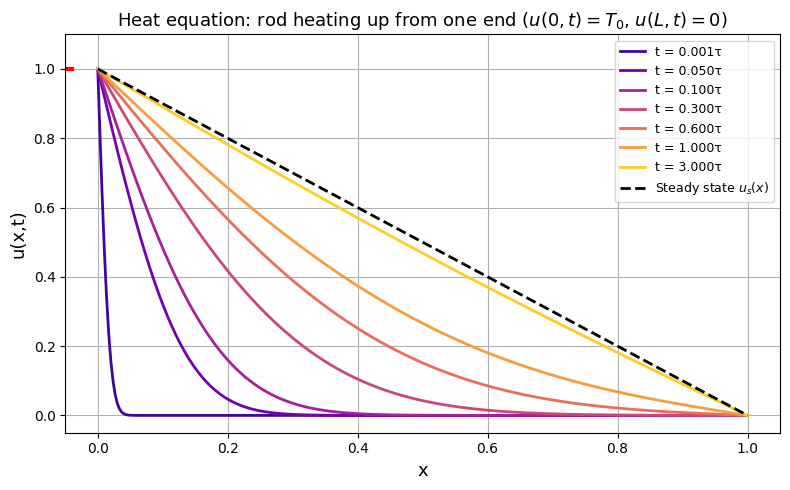

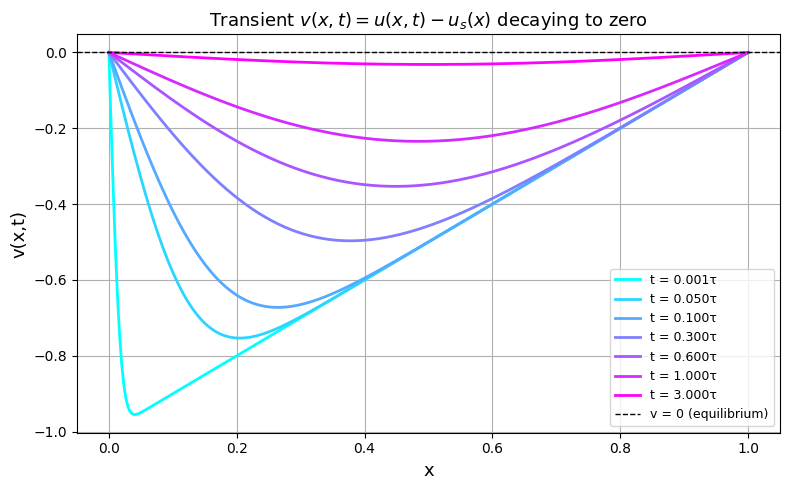

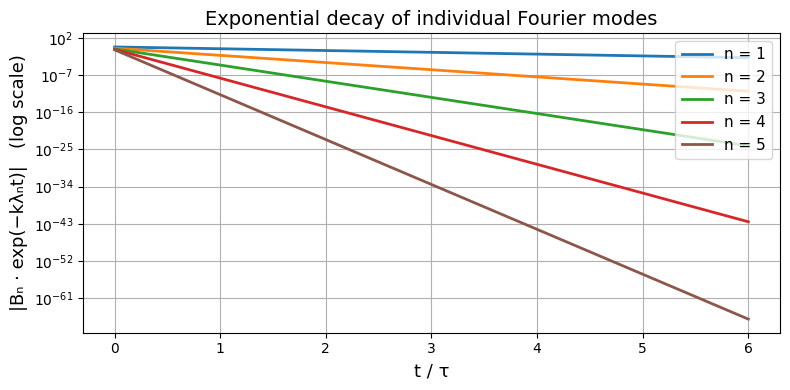

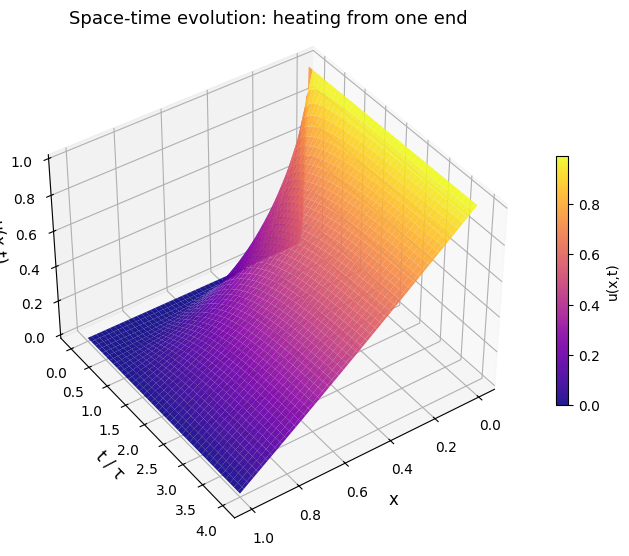

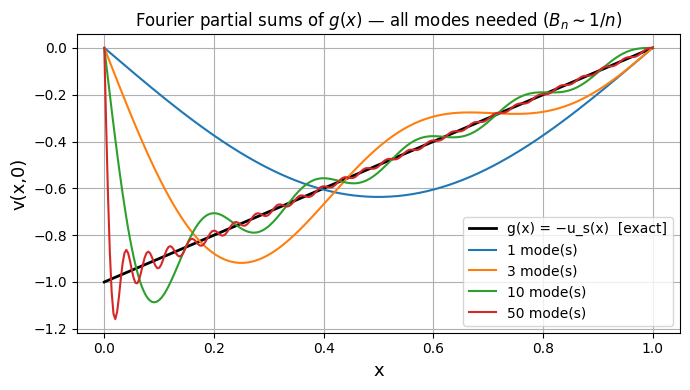

In [11]:
# =========================================================
#  Heat equation simulation: one end at constant temperature
#  u_t = k * u_xx,  x in [0,L],  t >= 0
#  BCs: u(0,t) = T0,  u(L,t) = 0
#  IC:  u(x,0) = 0
#
#  Decomposition: u(x,t) = u_s(x) + v(x,t)
#  Steady state:  u_s(x) = T0 * (1 - x/L)
#  Transient:     v(x,t) = sum of Fourier modes with IC g(x) = -u_s(x)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ── Parameters ────────────────────────────────────────────
L   = 1          # rod length
k   = 0.01       # thermal conductivity
T0  = 1.0        # temperature held at x = 0
N   = 100        # number of Fourier modes (all integers, not just odd)
tau = L**2 / (k * np.pi**2)   # characteristic decay timescale

# ── Spatial grid ──────────────────────────────────────────
x      = np.linspace(0, L, 300)
t_plot = np.array([0.001, 0.05, 0.1, 0.3, 0.6, 1.0, 3.0]) * tau

# ── Steady state ──────────────────────────────────────────
def steady_state(x, T0, L):
    return T0 * (1 - x / L)

# ── Fourier coefficients  B_n = -2*T0 / (n*pi)  for all n ─
n_arr = np.arange(1, N + 1)
B     = -2 * T0 / (n_arr * np.pi)


def transient(x, t, n_arr, B, k, L):
    """Evaluate the transient v(x,t) at given x and scalar t."""
    v = np.zeros_like(x, dtype=float)
    for n, b in zip(n_arr, B):
        v += b * np.sin(n * np.pi * x / L) * np.exp(-k * n**2 * np.pi**2 * t / L**2)
    return v


def full_solution(x, t, n_arr, B, k, L, T0):
    """u(x,t) = u_s(x) + v(x,t)"""
    return steady_state(x, T0, L) + transient(x, t, n_arr, B, k, L)


# ── Figure 1: temperature profiles at selected times ──────
fig1, ax1 = plt.subplots(figsize=(8, 5))
colors = cm.plasma(np.linspace(0.1, 0.9, len(t_plot)))

for i, t in enumerate(t_plot):
    u = full_solution(x, t, n_arr, B, k, L, T0)
    ax1.plot(x, u, color=colors[i], linewidth=2,
             label=f't = {t/tau:.3f}τ')

# Overlay steady state
us = steady_state(x, T0, L)
ax1.plot(x, us, 'k--', linewidth=2, label='Steady state $u_s(x)$')

# Mark the heat source end
ax1.axhline(y=T0, xmin=0, xmax=0.01, color='red', linewidth=3)

ax1.set_xlabel('x', fontsize=13)
ax1.set_ylabel('u(x,t)', fontsize=13)
ax1.set_title(
    'Heat equation: rod heating up from one end ($u(0,t)=T_0$, $u(L,t)=0$)',
    fontsize=13)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(-0.05, T0 * 1.1)
ax1.grid(True)
fig1.tight_layout()


# ── Figure 2: transient v(x,t) dying away ─────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
colors2 = cm.cool(np.linspace(0, 1, len(t_plot)))

for i, t in enumerate(t_plot):
    v = transient(x, t, n_arr, B, k, L)
    ax2.plot(x, v, color=colors2[i], linewidth=2,
             label=f't = {t/tau:.3f}τ')

ax2.axhline(0, color='k', linewidth=1, linestyle='--', label='v = 0 (equilibrium)')
ax2.set_xlabel('x', fontsize=13)
ax2.set_ylabel('v(x,t)', fontsize=13)
ax2.set_title('Transient $v(x,t) = u(x,t) - u_s(x)$ decaying to zero',
              fontsize=13)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True)
fig2.tight_layout()


# ── Figure 3: mode-by-mode decay (log scale) ──────────────
fig3, ax3 = plt.subplots(figsize=(8, 4))
t_fine      = np.linspace(1e-6, 6 * tau, 500)
mode_colors = plt.cm.tab10(np.linspace(0, 0.5, 5))

for idx in range(5):
    n   = n_arr[idx]
    amp = B[idx] * np.exp(-k * n**2 * np.pi**2 * t_fine / L**2)
    ax3.semilogy(t_fine / tau, np.abs(amp),
                 color=mode_colors[idx], linewidth=2,
                 label=f'n = {n}')

ax3.set_xlabel('t / τ', fontsize=13)
ax3.set_ylabel('|Bₙ · exp(−kλₙt)|   (log scale)', fontsize=13)
ax3.set_title('Exponential decay of individual Fourier modes', fontsize=14)
ax3.legend(loc='upper right', fontsize=11)
ax3.grid(True)
fig3.tight_layout()


# ── Figure 4: surface plot of full solution ───────────────
t_surf  = np.linspace(0.001 * tau, 4 * tau, 80)
U_surf  = np.array([full_solution(x, t, n_arr, B, k, L, T0) for t in t_surf])

X_grid, T_grid = np.meshgrid(x, t_surf / tau)

fig4  = plt.figure(figsize=(8, 5.5))
ax4   = fig4.add_subplot(111, projection='3d')
surf  = ax4.plot_surface(X_grid, T_grid, U_surf,
                         cmap='plasma', linewidth=0,
                         antialiased=True, alpha=0.92)
fig4.colorbar(surf, ax=ax4, shrink=0.5, label='u(x,t)')

ax4.set_xlabel('x', fontsize=12)
ax4.set_ylabel('t / τ', fontsize=12)
ax4.set_zlabel('u(x,t)', fontsize=12)
ax4.set_title('Space-time evolution: heating from one end', fontsize=13)
ax4.view_init(elev=40, azim=55)
fig4.tight_layout()


# ── Figure 5: Fourier partial sums of g(x) at t=0 ────────
# Shows that all modes are needed (1/n decay, not 1/n^3)
fig5, ax5 = plt.subplots(figsize=(7, 4))
g_exact = T0 * (x / L - 1)    # g(x) = -u_s(x)
ax5.plot(x, g_exact, 'k-', linewidth=2, label='g(x) = −u_s(x)  [exact]')

for M in [1, 3, 10, 50]:
    v_trunc = np.zeros_like(x, dtype=float)
    for idx in range(M):
        n        = n_arr[idx]
        v_trunc += B[idx] * np.sin(n * np.pi * x / L)
    ax5.plot(x, v_trunc, linewidth=1.5, label=f'{M} mode(s)')

ax5.set_xlabel('x', fontsize=13)
ax5.set_ylabel('v(x,0)', fontsize=13)
ax5.set_title('Fourier partial sums of $g(x)$ — all modes needed ($B_n \\sim 1/n$)',
              fontsize=12)
ax5.legend(loc='lower right', fontsize=10)
ax5.grid(True)
fig5.tight_layout()


# ── Console output ────────────────────────────────────────
print('\n=== Decay of modes after t = tau ===')
print(f'{"Mode n":<10}{"Bn":<14}{"Decay factor":<18}{"Relative to n=1":<18}')
ref = np.exp(-k * np.pi**2 * tau / L**2)
for idx in range(6):
    n  = n_arr[idx]
    df = np.exp(-k * n**2 * np.pi**2 * tau / L**2)
    print(f'{n:<10}{B[idx]:<14.5f}{df:<18.6f}{df/ref:<18.6f}')

print(f'\nCharacteristic timescale tau = {tau:.4f}')
print(f'Steady state: u_s(x) = {T0} * (1 - x/{L})')
print(f'Note: Bn ~ 1/n (slower convergence than parabolic case where Bn ~ 1/n^3)')

plt.show()